In [1]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [26]:
def parse_json1(data1):
    records = []
    for item in data1:
        records.append({
            'question_id': item['question_id'],
            'program_id': item['program_id'],
            'code_score': item['code_gpt_score']['code_gpt_score']
        })
    return pd.DataFrame(records)

In [27]:
def parse_json2(data2_list):
    records = []
    for item in data2_list:
        task_id = item['task_id']
        for key, value in item.items():
            if key.startswith('grade-'):
                program_id = key.split('-')[1] # 'grade-163' -> '163'
                records.append({
                    'question_id': task_id,
                    'program_id': program_id,
                    'execution_custom': value.get("execution_custom", 0.0) #경고 없으면 0.0가져오로독`` 임시 조치한것입니다. value['execution_custom'] 으로 바꿔주세요.
                })
    return pd.DataFrame(records)

In [32]:
def calculate_correlations(group):
    if len(group) < 2:
        return pd.Series({'Pearson_r': None, 'Spearman_rho': None, 'Kendall_tau': None})
    pearson = group['code_score'].corr(group['execution_custom'], method='pearson')
    spearman = group['code_score'].corr(group['execution_custom'], method='spearman')
    kendall = group['code_score'].corr(group['execution_custom'], method='kendall')
    
    return pd.Series({
        'Pearson_r': pearson, 
        'Spearman_rho': spearman, 
        'Kendall_tau': kendall
    })

In [29]:
def calculate(file1, file2):
    with open(file1) as f:
        data1 = json.load(f)
    with open(file2) as f:
        data2 = json.load(f)
    df1 = parse_json1(data1["data"])
    df2 = parse_json2(data2)
    df_merged = pd.merge(df1, df2, on=['question_id', 'program_id'], how='inner')

    df_valid = df_merged[df_merged['code_score'].between(0.0, 4.0)]

    results = df_valid.groupby('question_id').apply(calculate_correlations).reset_index()
    return results

In [68]:
ratio_files = ["../data/humaneval-x/humaneval_cpp_grade_evalplus_ratio.json", 
               "../data/humaneval-x/humaneval_go_grade_evalplus_ratio_bakj2.json", 
               "../data/humaneval-x/humaneval_java_grade_evalplus_ratio.json", 
               "../data/humaneval-x/humaneval_js_grade_evalplus_ratio.json", 
               "../data/humaneval-x/humaneval_python_grade_evalplus_ratio.json"]

judge_score_files = ["../codejudge_scripts/output/humaneval-x/cpp-small-test/ice_data_check/Qwen3-Next-80B-1-4-0.4-sample-0_icedata.json",
                     "../codejudge_scripts/output/humaneval-x/go-small-test/ice_data_check/Qwen3-Next-80B-1-4-0.4-sample-0_icedata.json",
                     "../codejudge_scripts/output/humaneval-x/java-small-test/ice_data_check/Qwen3-Next-80B-1-4-0.4-sample-0_icedata.json",
                     "../codejudge_scripts/output/humaneval-x/js-small-test/ice_data_check/Qwen3-Next-80B-1-4-0.4-sample-0_icedata.json",
                     "../codejudge_scripts/output/humaneval-x/python-small-test/ice_data_check/Qwen3-Next-80B-1-4-0.4-sample-0_icedata.json"]

language_name = ["CPP",
                 "Go",
                 "Java",
                 "Js",
                 "Python"]

#주의: 순서 안지키면 이상해집니다.

metric1 = "CJScore"
metric2 = "qwen3"

output_dir = "output/coeff_2"
os.makedirs(output_dir, exist_ok=True)


/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/yesng/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_2358639/2573786990.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_valid.groupby('question_id').apply(calculate_correlations).reset_index()


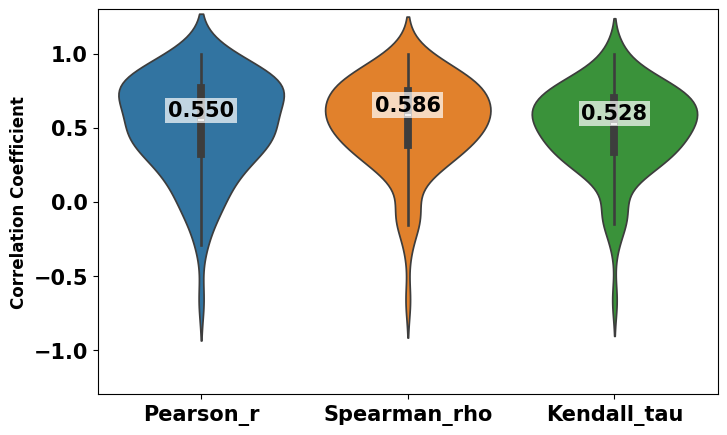

/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/yesng/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/tmp/ipykernel_2358639/2573786990.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_valid.groupby('question_id').apply(calculate_correlations).reset_index()


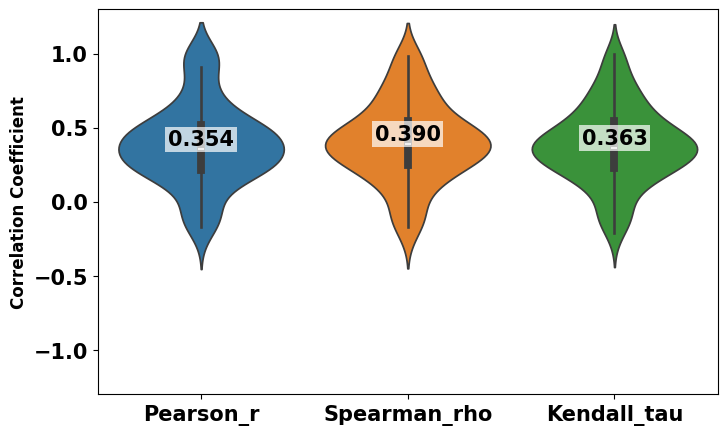

/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/yesng/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_2358639/2573786990.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_valid.groupby('question_id').apply(calculate_correlations).reset_index()


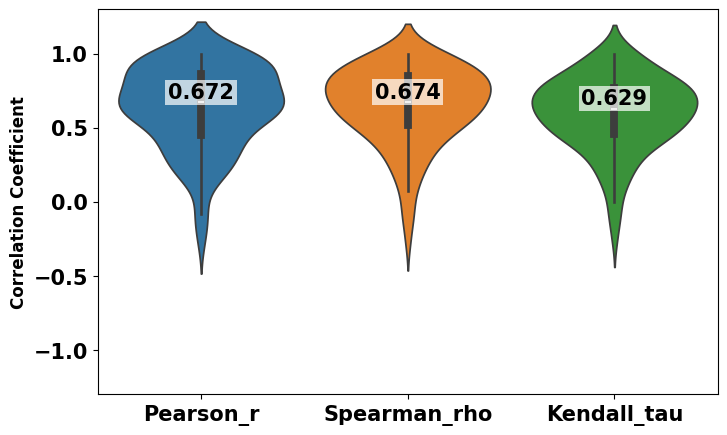

/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/yesng/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_2358639/2573786990.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_valid.groupby('question_id').apply(calculate_correlations).reset_index()


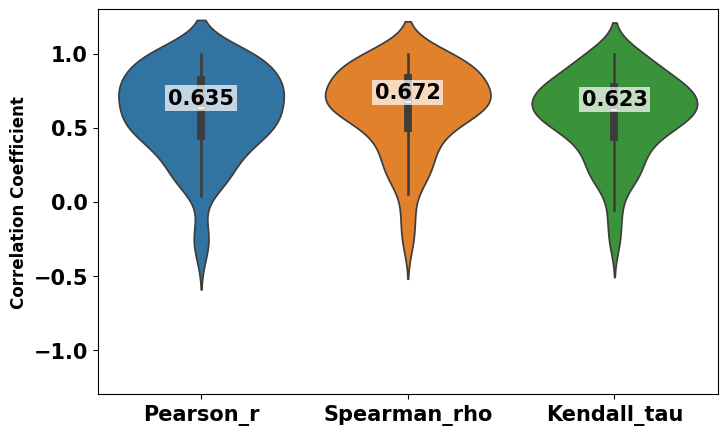

/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/yesng/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/yesng/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/tmp/ipykernel_2358639/2573786990.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_valid.groupby('question_id').apply(calculate_correlations).reset_index()


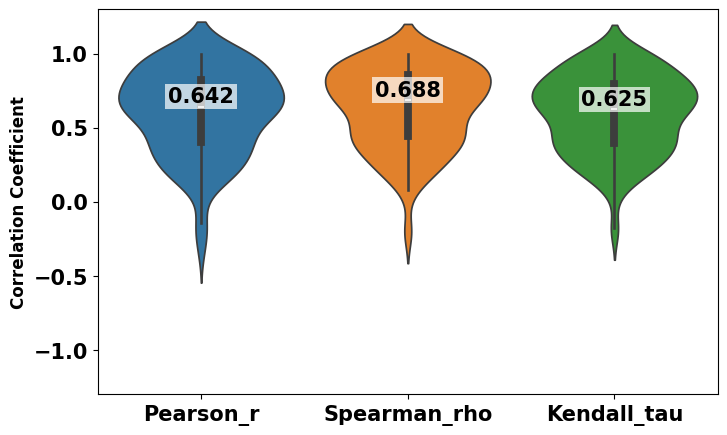

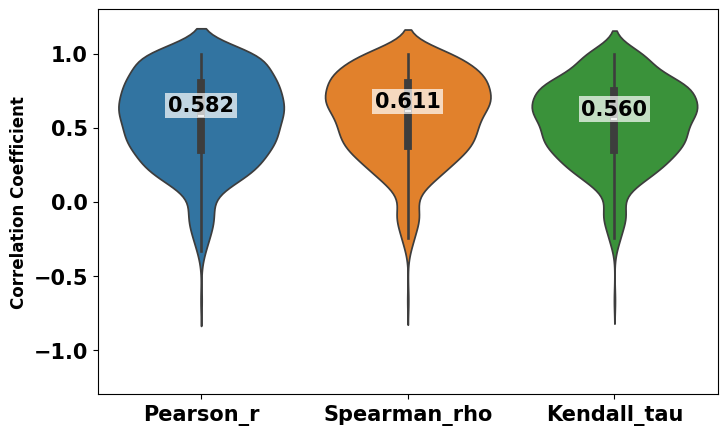

In [67]:
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 15
plt.rcParams['axes.labelsize'] = 12

all_results = []

for lang, f1, f2 in zip(language_name, judge_score_files, ratio_files):
    df_result = calculate(f1, f2)
    
    all_results.append(df_result)
    
    valid_result = df_result.dropna()
    
    plt.figure(figsize=(8, 5))
    ax = sns.violinplot(
        data=valid_result[['Pearson_r', 'Spearman_rho', 'Kendall_tau']],
    )
    medians = valid_result[['Pearson_r', 'Spearman_rho', 'Kendall_tau']].median()

    for i, median_val in enumerate(medians):
        ax.text(i, median_val, f'{median_val:.3f}',
                horizontalalignment='center',
                verticalalignment='bottom',
                weight='bold',
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))
    #plt.title(f'Correlation Distribution({lang}, {metric1}, {metric2})', fontsize=14)
    plt.ylabel('Correlation Coefficient')
    plt.ylim(-1.3, 1.3)
    
    
    file_name = f"{output_dir}/coeff_{metric1}_{metric2}_{lang}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')

    plt.show()

combined_results = pd.concat(all_results, ignore_index=True)
valid_combined = combined_results.dropna()

plt.figure(figsize=(8, 5))
ax = sns.violinplot(
    data=valid_combined[['Pearson_r', 'Spearman_rho', 'Kendall_tau']],
)

combined_medians = valid_combined[['Pearson_r', 'Spearman_rho', 'Kendall_tau']].median()

for i, median_val in enumerate(combined_medians):
    ax.text(i, median_val, f'{median_val:.3f}', 
            horizontalalignment='center', 
            verticalalignment='bottom', 
            weight='bold', 
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

#plt.title(f'Correlation Distribution(Overall, {metric1}, {metric2})', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.ylim(-1.3, 1.3)

overall_file_name = f"{output_dir}/coeff_{metric1}_{metric2}_overall.png"
plt.savefig(overall_file_name, dpi=300, bbox_inches='tight')
plt.show()